# Xarray + Cloud OISST (One-Month) Basics & Stats

This notebook demonstrates basic **xarray** operations on a **one-month** subset of a cloud-hosted climate dataset: **NOAA OISST v2.1 daily SST** on AWS Public Datasets (NetCDF files). You'll:
- Discover files for one month on S3 with `fsspec`
- Open them with `xarray.open_mfdataset` (anonymous S3)
- Inspect dataset structure
- Subset in space (and within that month)
- Compute basic stats (mean, std, anomalies relative to the month’s mean)
- Make maps of the month-mean and variability

**Deliverables:** Answer the **🧩 Questions** in the markdown prompts. Fill in the code where indicated by `# TODO`.


In [1]:
import xarray as xr
import fsspec
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['figure.dpi'] = 120


## 1) Open the cloud dataset (NetCDF on AWS, one month)

We'll access **NOAA OISST v2.1 (daily)** in the NOAA CDR bucket on AWS. Files are arranged by **YYYYMM**.

**🧩 Questions**
1. What engine are we using to read NetCDF files from S3?

   We are using the h5netcdf engine to read the files from s3.
   
2. Why do we need `storage_options={'anon': True}`?

   The 'storage_options={'anon': True}' argument is for security purposes and since this is a public dataset we can set anon to True.

   
3. Inspect dataset attributes: what are the units and long name of `sst`?

   The units for 'sst' are degrees Celcius and the long name is 'Daily sea surface temperature'.

In [6]:
yearmonth = "201908"  # TODO: try other months like "201507" or "201909"
prefix = f"noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/{yearmonth}/oisst-avhrr-v02r01.*.nc"

fs = fsspec.filesystem("s3", anon=True)
paths = sorted(fs.glob(prefix))
print(f"Found {len(paths)} files for {yearmonth}. Example:", paths[:2])

urls = [f"s3://{p}" for p in paths]

ds = xr.open_mfdataset(
    urls,
    engine="h5netcdf",
    combine="by_coords",
    decode_times=True,
    mask_and_scale=True,
    backend_kwargs={"storage_options": {"anon": True}},
    chunks={"time": 1}
)

ds


Found 31 files for 201908. Example: ['noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/201908/oisst-avhrr-v02r01.20190801.nc', 'noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/201908/oisst-avhrr-v02r01.20190802.nc']


<xarray.Dataset> Size: 514MB
Dimensions:  (time: 31, zlev: 1, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 248B 2019-08-01T12:00:00 ... 2019-08-31T12...
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
  * zlev     (zlev) float32 4B 0.0
Data variables:
    anom     (time, zlev, lat, lon) float32 129MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    err      (time, zlev, lat, lon) float32 129MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    ice      (time, zlev, lat, lon) float32 129MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    sst      (time, zlev, lat, lon) float32 129MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
Attributes: (12/37)
    source:                     ICOADS, NCEP_GTS, GSFC_ICE, NCEP_ICE, Pathfin...
    naming_authority:           gov.noaa.ncei
    cdm_data_type:              Grid
    date_modified:              2020-01-18T09:13:00Z
    date_created:               2020-01-18T09:13:00Z
    processing_level:           NOAA Level 4
    ...                         ...
    references:                 Reynolds, et al.(2007) Daily High-Resolution-...
    summary:                    NOAAs 1/4-degree Daily Optimum Interpolation ...
    product_version:            Version v02r01
    platform:                   Ships, buoys, Argo floats, MetOp-A, MetOp-B
    comment:                    Data was converted from NetCDF-3 to NetCDF-4 ...
    id:                         oisst-avhrr-v02r01.20190801.nc

## 2) Explore coordinates & variables

**🧩 Questions**
1. What are the coordinate names for time and space?

    The coordinate names for time and space are 'time', 'lat', 'lon' and 'zlev'

2. What is the shape of `sst`?

    The shape of 'sst' is (31,1,720,1440)

3. How are missing values represented?

    Missing values are represented as nans.


In [7]:
list(ds.data_vars), list(ds.coords)

(['anom', 'err', 'ice', 'sst'], ['time', 'lat', 'lon', 'zlev'])

## 3) Time & space subsetting

We'll select a **regional box** (e.g., Gulf of Mexico) within this month.

**🧩 Questions**
1. What lon/lat bounds did you choose?

    The Bay of Bengal. Longitudes 80 E to 90 E and latitudes 5 N to 22 N

2. How many daily steps are present in this month?

    There are 31 daily steps in this month


In [9]:
var = "sst"

lon_min, lon_max = 80, 90   # TODO
lat_min, lat_max =  5,  22   # TODO

def to_0360(lon):
    lon = np.asarray(lon)
    out = np.mod(lon, 360.0)
    out[out < 0] += 360.0
    return out

lon_min_0360, lon_max_0360 = to_0360([lon_min, lon_max])

dss = ds.sel(
    lon=slice(lon_min_0360, lon_max_0360),
    lat=slice(lat_min, lat_max)
)

dss[var]


<xarray.DataArray 'sst' (time: 31, zlev: 1, lat: 68, lon: 40)> Size: 337kB
dask.array<getitem, shape=(31, 1, 68, 40), dtype=float32, chunksize=(1, 1, 68, 40), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 248B 2019-08-01T12:00:00 ... 2019-08-31T12...
  * lat      (lat) float32 272B 5.125 5.375 5.625 5.875 ... 21.38 21.62 21.88
  * lon      (lon) float32 160B 80.12 80.38 80.62 80.88 ... 89.38 89.62 89.88
  * zlev     (zlev) float32 4B 0.0
Attributes:
    long_name:  Daily sea surface temperature
    valid_min:  -300
    valid_max:  4500
    units:      Celsius

## 4) Basic statistics

Compute region-wide stats through time and over space **within this month**.

**🧩 Questions**
1. Compute the spatial mean SST time series over your box. What is the monthly average and standard deviation?

    The monthly average sst is 28.83 C and the standard deviation is 0.097 C.

2. Compute within-month anomalies (subtract the month-mean). What are the largest positive and negative anomalies?

    The largest positive anomaly is 0.183 C and the largest negative anomaly is -0.158 C

3. What day had the warmest/coolest region-mean SST?

    The warmest day was 2019-08-01 and the coolest day was 2019-08-12.


Month mean SST (°C): 28.833698272705078
Month std SST (°C): 0.09681808948516846


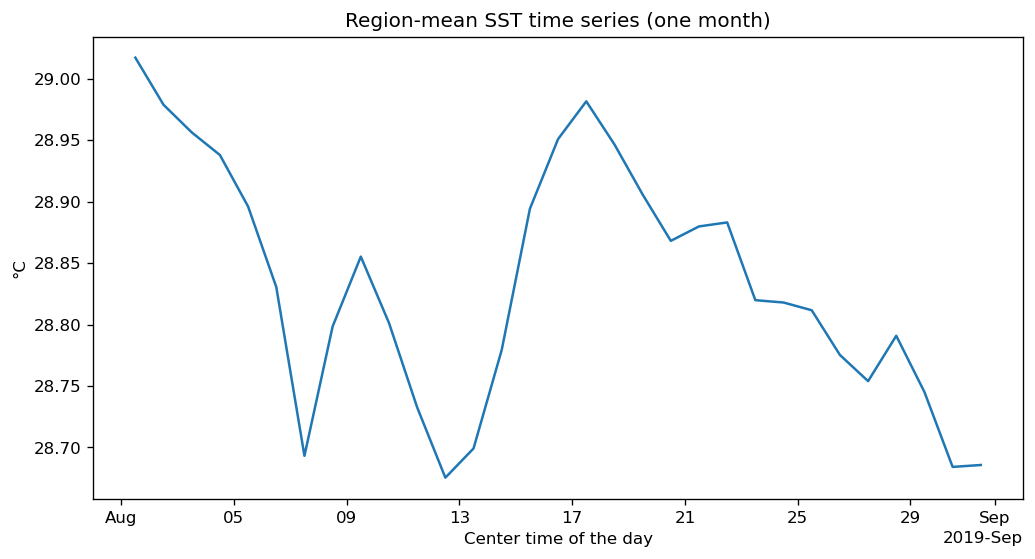

Warmest day: 2019-08-01 29.016979217529297
Coolest day: 2019-08-12 28.67546844482422


/var/folders/8t/4dcpfx6j29d858grh_vp_d_m0000gn/T/ipykernel_29034/4235597154.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Warmest day:', pd.to_datetime(ts.time[imax].values).date(), float(ts.isel(time=imax).values))
/var/folders/8t/4dcpfx6j29d858grh_vp_d_m0000gn/T/ipykernel_29034/4235597154.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Coolest day:', pd.to_datetime(ts.time[imin].values).date(), float(ts.isel(time=imin).values))


In [10]:
ts = dss[var].mean(dim=['lat','lon'])

ts_mean = ts.mean().compute()
ts_std  = ts.std().compute()
print('Month mean SST (°C):', float(ts_mean.values))
print('Month std SST (°C):', float(ts_std.values))

ts.load().plot()
plt.title('Region-mean SST time series (one month)')
plt.ylabel('°C')
plt.show()

imax = int(ts.argmax('time'))
imin = int(ts.argmin('time'))
print('Warmest day:', pd.to_datetime(ts.time[imax].values).date(), float(ts.isel(time=imax).values))
print('Coolest day:', pd.to_datetime(ts.time[imin].values).date(), float(ts.isel(time=imin).values))


Max anomaly (°C): 0.18328018486499786
Min anomaly (°C): -0.15823176503181458


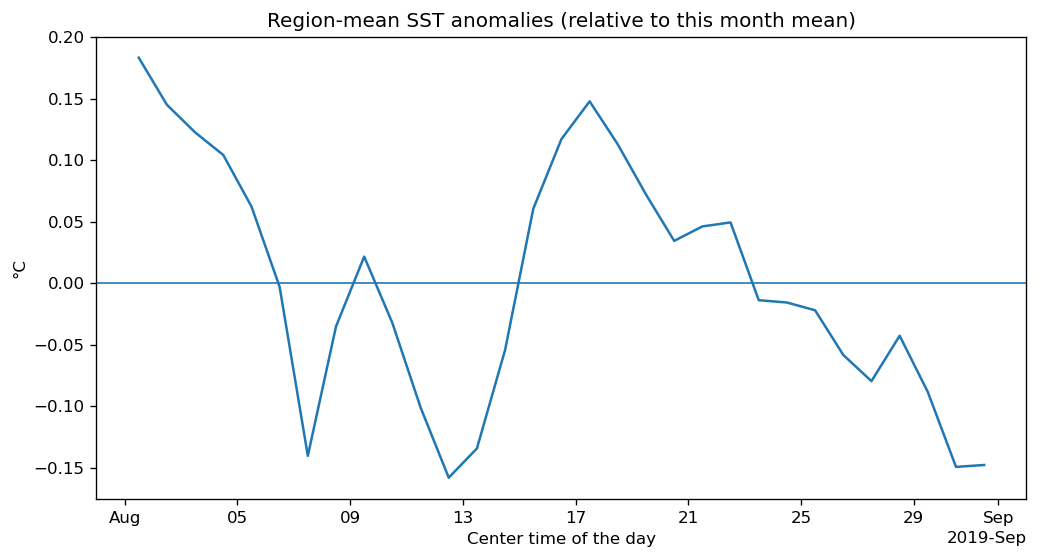

In [11]:
month_mean = dss[var].mean('time')
anom = dss[var] - month_mean

ts_anom = anom.mean(dim=['lat','lon'])
print('Max anomaly (°C):', float(ts_anom.max().compute().values))
print('Min anomaly (°C):', float(ts_anom.min().compute().values))

ts_anom.load().plot()
plt.title('Region-mean SST anomalies (relative to this month mean)')
plt.axhline(0, lw=1)
plt.ylabel('°C')
plt.show()


## 5) Regional maps: month-mean and variability

Make maps of month-mean SST and within-month variability (std and range).

**🧩 Questions**
1. What patterns do you notice?

    There is an anomalously cool area north of Sri Lanka off the Indian coast

2. Where is variability strongest?

    The variability is strongest near the coast of India


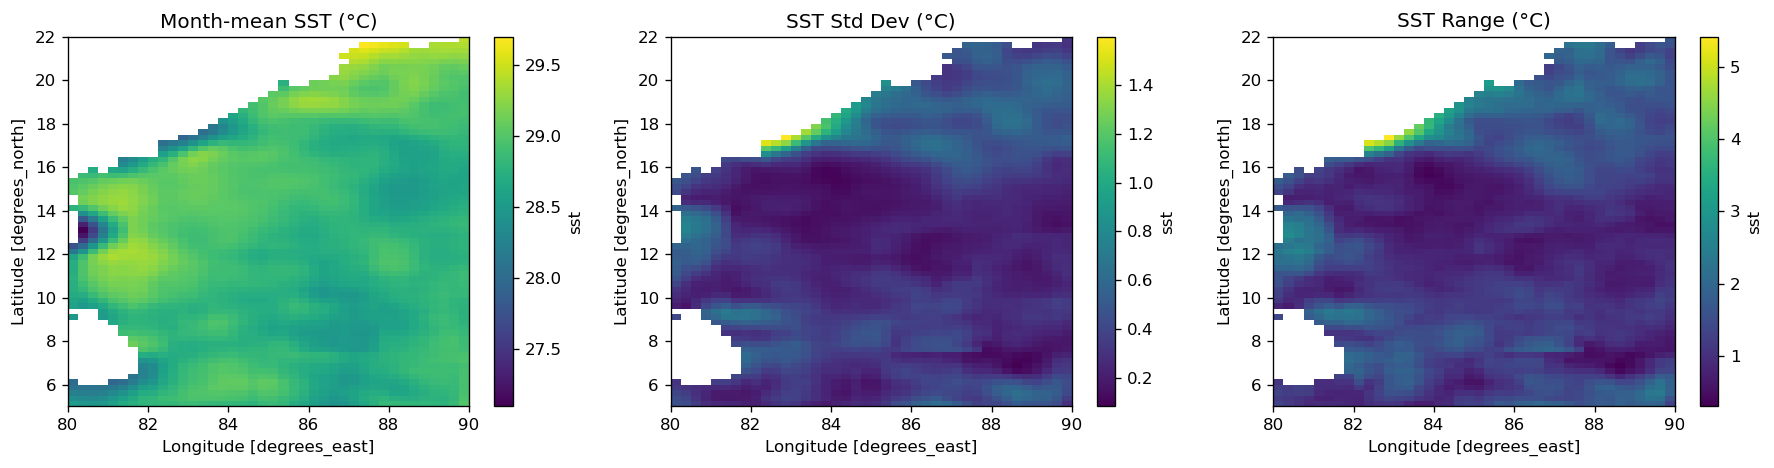

In [12]:
mean_sst = dss[var].mean('time')
std_sst  = dss[var].std('time')
range_sst = dss[var].max('time') - dss[var].min('time')

fig = plt.figure(figsize=(15,4))
ax = plt.subplot(1,3,1); mean_sst.plot(ax=ax); ax.set_title('Month-mean SST (°C)')
ax = plt.subplot(1,3,2); std_sst.plot(ax=ax); ax.set_title('SST Std Dev (°C)')
ax = plt.subplot(1,3,3); range_sst.plot(ax=ax); ax.set_title('SST Range (°C)')
plt.tight_layout(); plt.show()


## 6) Export a small subset for sharing (Check In Problem for Module 2)

Write a NetCDF with your regional mean time series and month-mean/variability maps.  Upload with your committed repository.

In [13]:
bayofbengal = xr.Dataset(data_vars={'Mean SST Time Series': ts, 'Mean SST Anomaly Time Series': ts_anom, 
                                    'Mean SST': mean_sst, 'SST Standard Deviation': std_sst, 'SST Range': range_sst})

bayofbengal

<xarray.Dataset> Size: 34kB
Dimensions:                       (time: 31, zlev: 1, lat: 68, lon: 40)
Coordinates:
  * time                          (time) datetime64[ns] 248B 2019-08-01T12:00...
  * zlev                          (zlev) float32 4B 0.0
  * lat                           (lat) float32 272B 5.125 5.375 ... 21.62 21.88
  * lon                           (lon) float32 160B 80.12 80.38 ... 89.62 89.88
Data variables:
    Mean SST Time Series          (time, zlev) float32 124B 29.02 ... 28.69
    Mean SST Anomaly Time Series  (time, zlev) float32 124B 0.1833 ... -0.1479
    Mean SST                      (zlev, lat, lon) float32 11kB dask.array<chunksize=(1, 68, 40), meta=np.ndarray>
    SST Standard Deviation        (zlev, lat, lon) float32 11kB dask.array<chunksize=(1, 68, 40), meta=np.ndarray>
    SST Range                     (zlev, lat, lon) float32 11kB dask.array<chunksize=(1, 68, 40), meta=np.ndarray>

In [14]:
bayofbengal.to_netcdf('bayofbengal.nc')